# Anomaly Detection Using Isolation Forest

**CMPE 255 — Assignment 1, Part 2**

This experiment replicates and simplifies an anomaly detection workflow using
server telemetry data from the Pooled Server Metrics (PSM) dataset.

The goal is to detect unusual server behavior using an unsupervised machine
learning algorithm and compare the detected anomalies with the available
ground-truth labels.

## Workflow

1. Load and inspect the PSM dataset
2. Check missing values and data structure
3. Prepare numerical telemetry features
4. Standardize the features
5. Train an Isolation Forest model
6. Generate anomaly scores and predictions
7. Compare predictions with ground-truth anomaly labels
8. Visualize normal and anomalous observations using PCA
9. Interpret the detected anomalies

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix


# -------------------------
# 1. Data paths
# -------------------------

data_dir = Path("../data").resolve()

train_path = data_dir / "train.csv"
test_path = data_dir / "test.csv"
label_path = data_dir / "test_label.csv"

print("Train exists:", train_path.exists())
print("Test exists:", test_path.exists())
print("Label exists:", label_path.exists())


# -------------------------
# 2. Load data
# -------------------------

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
labels_df = pd.read_csv(label_path)

print("\nTrain shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Labels shape:", labels_df.shape)


# -------------------------
# 3. Select features
# -------------------------

feature_cols = [
    col for col in train_df.columns
    if col != "timestamp_(min)"
]

X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_test = labels_df["label"]


# -------------------------
# 4. Missing-value handling
# -------------------------

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)


# -------------------------
# 5. Scaling
# -------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("\nNumber of features:", len(feature_cols))
print("Train NaNs:", np.isnan(X_train_scaled).sum())
print("Test NaNs:", np.isnan(X_test_scaled).sum())

print("\nSetup complete.")

Train exists: True
Test exists: True
Label exists: True

Train shape: (132481, 26)
Test shape: (87841, 26)
Labels shape: (87841, 2)

Number of features: 25
Train NaNs: 0
Test NaNs: 0

Setup complete.


In [2]:
display(train_df.head())
display(test_df.head())
display(labels_df.head())

,timestamp_(min),feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
0,0.0,0.732689,0.761748,0.606848,0.488746,0.424310,0.403609,0.519318,0.398792,0.451453,...,0.318797,0.451856,0.571500,0.469717,0.609883,0.008432,0.0,0.481838,0.006536,0.138249
1,1.0,0.732799,0.761855,0.607133,0.488781,0.432008,0.410256,0.511364,0.402568,0.455657,...,0.321463,0.456123,0.562226,0.466533,0.629812,0.008432,0.0,0.477218,0.006536,0.115207
2,2.0,0.732938,0.761594,0.606895,0.488791,0.418858,0.407724,0.488636,0.396526,0.456104,...,0.347219,0.456692,0.572002,0.487845,0.643598,0.006745,0.0,0.492623,0.008715,0.092166
3,3.0,0.732893,0.761656,0.606478,0.488802,0.417896,0.404242,0.500000,0.405589,0.460020,...,0.361904,0.460532,0.563354,0.479512,0.644690,0.008432,0.0,0.457064,0.008715,0.142857
4,4.0,0.732788,0.761573,0.606777,0.488800,0.421103,0.407407,0.511364,0.399547,0.458507,...,0.359767,0.458825,0.563354,0.448298,0.629948,0.006745,0.0,0.472223,0.006536,0.170507


,timestamp_(min),feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,...,feature_15,feature_16,feature_17,feature_18,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24
0,132480.0,0.775374,0.909185,0.606704,0.660626,0.449968,0.426717,0.471591,0.434668,0.479511,...,0.400617,0.480444,0.588670,0.404036,0.638957,0.020236,0.042705,0.173375,0.008715,0.105991
1,132481.0,0.775423,0.909142,0.607796,0.660655,0.487813,0.442545,0.505682,0.448640,0.499451,...,0.396902,0.500213,0.587041,0.421605,0.637865,0.018550,0.042705,0.191826,0.010893,0.110599
2,132482.0,0.775458,0.909004,0.607988,0.660623,0.469532,0.433682,0.477273,0.450906,0.487223,...,0.389270,0.487982,0.582404,0.407393,0.636091,0.018550,0.039146,0.188361,0.010893,0.115207
3,132483.0,0.775513,0.909200,0.607218,0.660640,0.459910,0.435581,0.482955,0.454683,0.490431,...,0.403780,0.491253,0.584660,0.407141,0.638138,0.020236,0.042705,0.186975,0.013072,0.110599
4,132484.0,0.775587,0.909318,0.606654,0.660643,0.462155,0.436214,0.477273,0.449396,0.494671,...,0.403636,0.495947,0.581527,0.402761,0.632678,0.021922,0.042705,0.156325,0.008715,0.110599


,timestamp_(min),label
0,132480.0,0
1,132481.0,0
2,132482.0,0
3,132483.0,0
4,132484.0,0


## Data Preparation

The dataset contains 25 numerical telemetry features and a timestamp column.

The timestamp is retained for reference but excluded from model training because
it represents observation order rather than a telemetry measurement.

The training dataset contains missing values in several features, while the
test dataset does not contain missing values.

Missing training values are replaced using the median calculated from the
training data. The same preprocessing transformation is then applied to the
test data.

The numerical features are also standardized before anomaly detection.

In [3]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Labels shape:", labels_df.shape)

print(
    "Test/label timestamps aligned:",
    np.allclose(
        test_df["timestamp_(min)"],
        labels_df["timestamp_(min)"]
    )
)

print(
    "Anomaly rate:",
    labels_df["label"].mean()
)

Train shape: (132481, 26)
Test shape: (87841, 26)
Labels shape: (87841, 2)
Test/label timestamps aligned: True
Anomaly rate: 0.27755831559294636


## Isolation Forest Model

Isolation Forest is an unsupervised anomaly detection algorithm.

The model is trained only on the training telemetry data and does not use the
test anomaly labels during training.

Isolation Forest identifies observations that are easier to isolate from the
rest of the data as potential anomalies.

The test labels are used only after prediction to evaluate how well the
unsupervised model detects known anomalies.

In [4]:
model = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_scaled)

print("Isolation Forest training complete.")

Isolation Forest training complete.


In [5]:
if_predictions = model.predict(X_test_scaled)

print("Raw Isolation Forest predictions:")
print(pd.Series(if_predictions).value_counts())

Raw Isolation Forest predictions:
 1    79059
-1     8782
Name: count, dtype: int64


In [6]:
y_pred = np.where(if_predictions == -1, 1, 0)

print("Converted predictions:")
print(pd.Series(y_pred).value_counts())

print("\nPredicted anomaly rate:")
print(y_pred.mean())

Converted predictions:
0    79059
1     8782
Name: count, dtype: int64

Predicted anomaly rate:
0.09997609316833825


In [17]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Anomaly"],
    output_dict=True
)

report_rows = []

for name in ["Normal", "Anomaly", "macro avg", "weighted avg"]:
    metrics = report[name]

    report_rows.append({
        "class": name,
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1-score"],
        "support": metrics["support"],
        "accuracy": np.nan
    })

report_rows.append({
    "class": "accuracy",
    "precision": np.nan,
    "recall": np.nan,
    "f1_score": np.nan,
    "support": len(y_test),
    "accuracy": report["accuracy"]
})

report_df = pd.DataFrame(report_rows)

report_df.to_csv(
    "../results/classification_report.csv",
    index=False
)

display(report_df)

,class,precision,recall,f1_score,support,accuracy
0,Normal,0.754171,0.939552,0.836717,63460.0,NaN
1,Anomaly,0.563197,0.202863,0.298284,24381.0,NaN
2,macro avg,0.658684,0.571208,0.567500,87841.0,NaN
3,weighted avg,0.701165,0.735078,0.687270,87841.0,NaN
4,accuracy,NaN,NaN,NaN,87841.0,0.735078


In [8]:
anomaly_scores = -model.decision_function(X_test_scaled)

results_df = pd.DataFrame({
    "timestamp_(min)": test_df["timestamp_(min)"],
    "true_label": y_test.values,
    "predicted_label": y_pred,
    "anomaly_score": anomaly_scores
})

display(
    results_df
    .sort_values("anomaly_score", ascending=False)
    .head(10)
)

,timestamp_(min),true_label,predicted_label,anomaly_score
3363,135843.0,1,1,0.226633
3361,135841.0,1,1,0.226424
3371,135851.0,1,1,0.225719
3362,135842.0,1,1,0.223668
3368,135848.0,1,1,0.223274
3369,135849.0,1,1,0.222604
3351,135831.0,1,1,0.222296
3348,135828.0,1,1,0.222046
3374,135854.0,1,1,0.218686
3360,135840.0,1,1,0.218658


## Model Evaluation

The Isolation Forest achieved an overall accuracy of approximately 74%.

However, accuracy alone is not sufficient for evaluating anomaly detection
because the dataset contains substantially more normal observations than
anomalies.

For the anomaly class:

- Precision: approximately 0.56
- Recall: approximately 0.20
- F1-score: approximately 0.30

The model correctly detected 4,946 anomalous observations but missed 19,435
known anomalies.

At the same time, it correctly classified 59,624 normal observations and
incorrectly flagged 3,836 normal observations as anomalies.

This indicates that the default Isolation Forest configuration is relatively
conservative. It identifies a smaller group of unusual observations with
moderate precision, but it fails to detect many of the anomalies contained in
the ground-truth labels.

Therefore, the 74% overall accuracy should not be interpreted as strong anomaly
detection performance. Recall and F1-score provide a more informative view of
the model's ability to detect anomalies.

In [9]:
pca = PCA(n_components=2)

pca.fit(X_train_scaled)

X_test_pca = pca.transform(X_test_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Explained variance ratio:
[0.54169699 0.10398187]
Total explained variance: 0.6456788525383821


In [10]:
pca_df = pd.DataFrame({
    "PC1": X_test_pca[:, 0],
    "PC2": X_test_pca[:, 1],
    "Predicted": y_pred,
    "TrueLabel": y_test.values
})

pca_df.head()

,PC1,PC2,Predicted,TrueLabel
0,-3.070783,1.962449,0,0
1,-2.329224,1.590505,0,0
2,-2.814659,1.746270,0,0
3,-2.425352,2.156306,0,0
4,-2.822801,1.996845,0,0


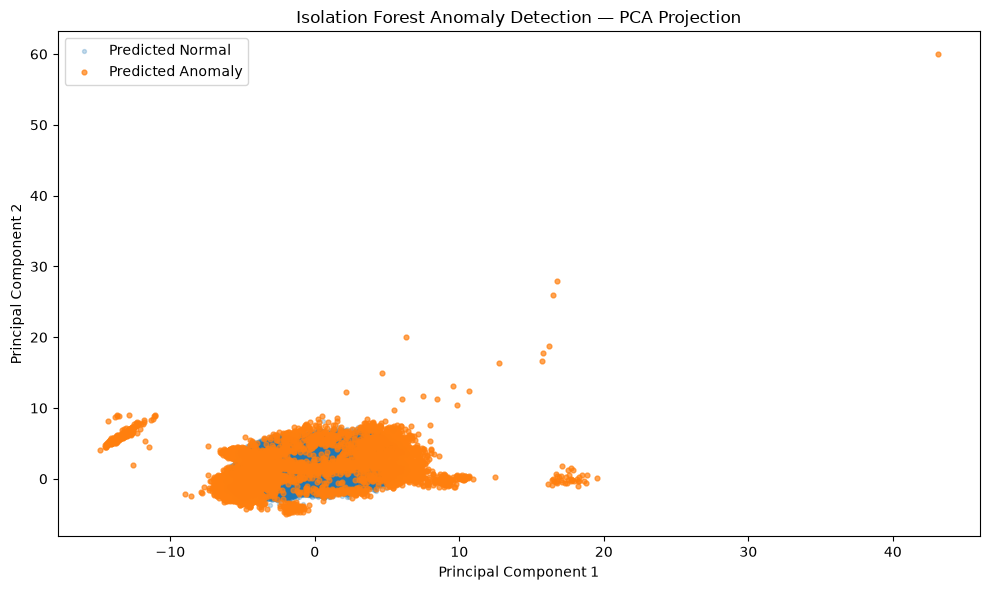

In [11]:
plt.figure(figsize=(10, 6))

normal = pca_df[pca_df["Predicted"] == 0]
anomaly = pca_df[pca_df["Predicted"] == 1]

plt.scatter(
    normal["PC1"],
    normal["PC2"],
    s=8,
    alpha=0.25,
    label="Predicted Normal"
)

plt.scatter(
    anomaly["PC1"],
    anomaly["PC2"],
    s=12,
    alpha=0.7,
    label="Predicted Anomaly"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Isolation Forest Anomaly Detection — PCA Projection")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/isolation_forest_pca.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

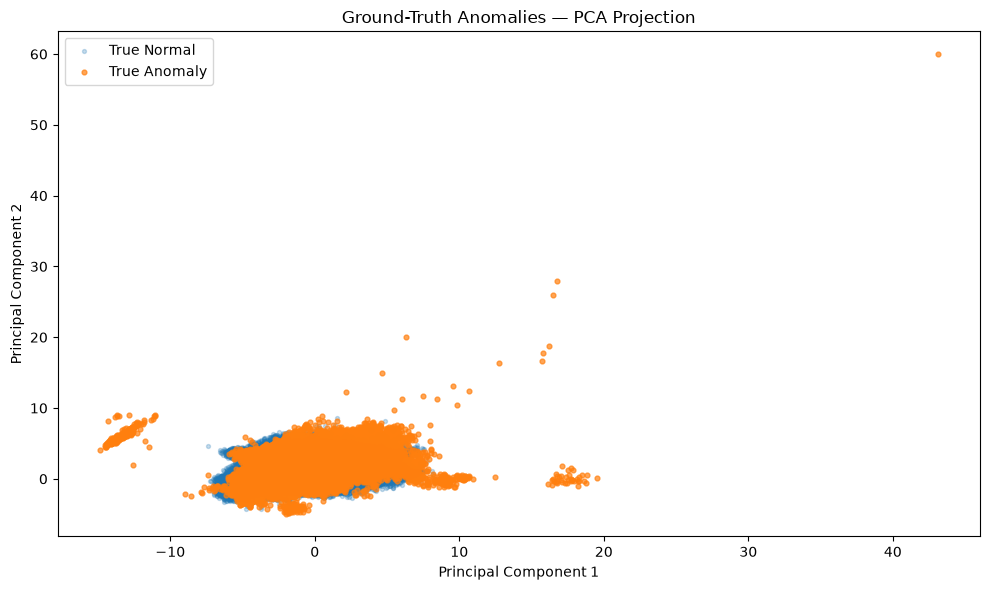

In [12]:
plt.figure(figsize=(10, 6))

normal = pca_df[pca_df["TrueLabel"] == 0]
anomaly = pca_df[pca_df["TrueLabel"] == 1]

plt.scatter(
    normal["PC1"],
    normal["PC2"],
    s=8,
    alpha=0.25,
    label="True Normal"
)

plt.scatter(
    anomaly["PC1"],
    anomaly["PC2"],
    s=12,
    alpha=0.7,
    label="True Anomaly"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Ground-Truth Anomalies — PCA Projection")
plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/ground_truth_pca.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [13]:
results_df.to_csv(
    "../results/anomaly_predictions.csv",
    index=False
)

print("Saved anomaly_predictions.csv")

Saved anomaly_predictions.csv


In [14]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["True Normal", "True Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

cm_df.to_csv("../results/confusion_matrix.csv")

display(cm_df)

,Predicted Normal,Predicted Anomaly
True Normal,59624,3836
True Anomaly,19435,4946


## Final Conclusion

This experiment applied Isolation Forest to the Pooled Server Metrics (PSM)
dataset to detect anomalous server telemetry observations.

The model was trained using 25 numerical telemetry features. The timestamp was
excluded from model training, missing training values were replaced using
training-set medians, and the numerical features were standardized.

Isolation Forest was trained only on the training telemetry data without using
the test anomaly labels.

### Evaluation Results

The final model achieved:

- Accuracy: approximately **0.74**
- Anomaly precision: approximately **0.56**
- Anomaly recall: approximately **0.20**
- Anomaly F1-score: approximately **0.30**

The confusion matrix showed:

- 59,624 normal observations correctly classified as normal
- 3,836 normal observations incorrectly flagged as anomalies
- 19,435 anomalous observations missed by the model
- 4,946 anomalous observations correctly detected

Although the overall accuracy was approximately 74%, this value alone is
misleading because normal observations are more common than anomalies.

The anomaly recall of approximately 20% shows that the default Isolation
Forest configuration detected only a portion of the known anomalies.

Therefore, the model can identify some unusual observations, but it should not
be considered a strong anomaly detector for this dataset without further
threshold tuning, feature engineering, or model comparison.

### PCA Visualization

PCA was used to project the 25 telemetry features into two dimensions for
visualization.

The explained variance ratios were approximately:

- PC1: **54.17%**
- PC2: **10.40%**
- Total: **64.57%**

The PCA visualizations showed that some extreme anomalous observations were
clearly separated from the main data distribution.

However, many ground-truth anomalies overlapped with normal observations in
the two-dimensional PCA space.

This helps explain why Isolation Forest successfully detected some extreme
observations but missed many known anomalies.

PCA was used only for visualization. The Isolation Forest model itself used
all 25 standardized telemetry features.

In [ ]:
report = classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Anomaly"],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../results/classification_report.csv"
)

results_df.to_csv(
    "../results/anomaly_predictions.csv",
    index=False
)

cm_df.to_csv(
    "../results/confusion_matrix.csv"
)

print("All result files saved.")

All result files saved.
